# [Workshop] 수입신고 우범화물 예측
- Machine Learning · 이진 분류 (불균형 데이터)
- 관세청 수입신고 데이터를 이용해 각 신고 건이 **우범(1)** 인지 **정상(0)** 인지 예측합니다.
- 데이터: `CustomsDeclaration.csv` — 실제 신고 데이터를 CTGAN으로 합성한 공개 데이터 ([출처](https://github.com/Seondong/Customs-Declaration-Datasets), MIT License)

| 단계 | 내용 |
|:--|:--|
| 1 | 기본 데이터 분석 (EDA) |
| 2 | 데이터 전처리 |
| 3 | 머신러닝 적용 (1차) → **정확도의 함정** 확인 |
| 4 | 성능 개선 ① 로그 변환 · 스케일링 · **불균형 처리** → 머신러닝 (2차) |
| 5 | 성능 개선 ② 파생 변수 생성 → 머신러닝 (3차) |
| 6 | 최종 모델 변수 중요도 |

<br/>
<br/>

### 모듈 import

In [1]:
# 한글 폰트 설정
# - Google Colab 사용 시 아래 주석을 해제하여 나눔폰트를 설치한 뒤 런타임을 재시작하세요.
# !sudo apt-get install -y fonts-nanum && sudo fc-cache -fv && rm -rf ~/.cache/matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 (Colab: NanumGothic / Windows: Malgun Gothic / Mac: AppleGothic)
import matplotlib.font_manager as fm
for _f in ['NanumGothic', 'Malgun Gothic', 'AppleGothic']:
    if any(_f == f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False

<br/>
<br/>

### 데이터 로드
- `CustomsDeclaration.csv` 파일을 읽어 `df` 에 저장하세요.

In [3]:
df = pd.read_csv('CustomsDeclaration.csv')
df.head()

,Declaration ID,Date,Office ID,Process Type,Import Type,Import Use,Payment Type,Mode of Transport,Declarant ID,Importer ID,...,HS6 Code,Country of Departure,Country of Origin,Tax Rate,Tax Type,Country of Origin Indicator,Net Mass,Item Price,Fraud,Critical Fraud
0,97061800,2020-01-01,30,B,11,21,11,10,ZZR1LT6,QLRUBN9,...,440890,BE,BE,0.0,FEU1,G,108.0,372254.40,0,0
1,85945189,2020-01-01,40,B,11,21,11,40,SWF9S4X,7JD1S2X,...,690722,CN,CN,8.0,A,Y,11352.0,375751.20,0,0
2,77854751,2020-01-01,20,B,11,21,11,40,X4XT6P8,WI9O3I5,...,620822,CN,CN,5.2,FCN1,B,20.7,5353.02,0,0
3,46925060,2020-01-01,40,B,11,21,43,40,K7LCQTZ,6LI9721,...,940350,VN,VN,0.0,C,Y,9218.0,1477645.40,0,0
4,34131149,2020-01-01,20,B,11,21,11,10,1HMVIVH,RZ871V1,...,71080,VN,VN,27.0,A,B,24000.0,6364800.00,0,0


### 컬럼명 한글로 변경
- 이후 분석의 편의를 위해 영문 컬럼명을 한글로 바꿉니다.

In [4]:
# 컬럼명을 한글로 변경하세요.
df = df.rename(columns={
    'Declaration ID': '신고번호', 'Date': '신고일자', 'Office ID': '세관부호',
    'Process Type': '신고구분', 'Import Type': '수입유형', 'Import Use': '수입용도',
    'Payment Type': '납부방법', 'Mode of Transport': '운송수단',
    'Declarant ID': '신고인부호', 'Importer ID': '수입자부호', 'Seller ID': '판매자부호',
    'Courier ID': '특송업체부호', 'HS6 Code': 'HS6단위', 'Country of Departure': '적출국',
    'Country of Origin': '원산지국', 'Tax Rate': '세율', 'Tax Type': '관세종류',
    'Country of Origin Indicator': '원산지표시', 'Net Mass': '순중량',
    'Item Price': '신고가격', 'Fraud': '우범여부', 'Critical Fraud': '중대우범여부',
})
df.head()

,신고번호,신고일자,세관부호,신고구분,수입유형,수입용도,납부방법,운송수단,신고인부호,수입자부호,...,HS6단위,적출국,원산지국,세율,관세종류,원산지표시,순중량,신고가격,우범여부,중대우범여부
0,97061800,2020-01-01,30,B,11,21,11,10,ZZR1LT6,QLRUBN9,...,440890,BE,BE,0.0,FEU1,G,108.0,372254.40,0,0
1,85945189,2020-01-01,40,B,11,21,11,40,SWF9S4X,7JD1S2X,...,690722,CN,CN,8.0,A,Y,11352.0,375751.20,0,0
2,77854751,2020-01-01,20,B,11,21,11,40,X4XT6P8,WI9O3I5,...,620822,CN,CN,5.2,FCN1,B,20.7,5353.02,0,0
3,46925060,2020-01-01,40,B,11,21,43,40,K7LCQTZ,6LI9721,...,940350,VN,VN,0.0,C,Y,9218.0,1477645.40,0,0
4,34131149,2020-01-01,20,B,11,21,11,10,1HMVIVH,RZ871V1,...,71080,VN,VN,27.0,A,B,24000.0,6364800.00,0,0


- 컬럼 설명

| 컬럼 | 의미 · 값 설명 | | 컬럼 | 의미 · 값 설명 |
|:--|:--|:--|:--|:--|
| 신고번호 | 신고 고유번호 | | HS6단위 | 품목 6자리 코드 (앞 2자리=대분류) |
| 신고일자 | 신고 일자 (2020~2021) | | 적출국 | 선적 출발국 (국가 2자리 코드) |
| 세관부호 | 통관 세관 (코드값) | | 원산지국 | 제조·생산국 (국가 2자리 코드) |
| 신고구분 | 신고 처리 구분 (코드값) | | 세율 | 관세율(%), 0~수십% |
| 수입유형 | 수입 유형 (코드값) | | 관세종류 | 관세 종류 (코드값) |
| 수입용도 | 수입 용도 (코드값) | | 원산지표시 | 원산지 표시 구분 (코드값) |
| 납부방법 | 관세 납부 방법 (코드값) | | 순중량 | 순중량(kg) |
| 운송수단 | 운송 수단 (코드값) | | 신고가격 | 신고 가격(KRW) |
| 신고인·수입자·판매자·특송업체부호 | 각 주체 식별자(ID) | | **우범여부** | **예측 대상** |
| | | | 중대우범여부 | 우범의 심각도 |

- **타깃 값의 의미**
    - `우범여부` (예측 대상) : **0 = 정상**, **1 = 우범**(수입검사 결과 이상이 발견된 신고)
    - `중대우범여부` : **0 = 정상**, **1 = 우범**, **2 = 중대 우범**(관세 포탈 등 고위험) — 우범여부보다 세분화된 라벨
    - ※ 세관·유형·용도 등 코드값은 실제 코드 체계를 익명화한 것으로, **값 자체보다 '어떤 코드에서 우범이 많은가'** 를 학습에 활용합니다.

<br/>
<br/>

## 1. 기본 데이터 분석 (EDA)

### 데이터 크기 · 기본 정보

In [5]:
# df의 행/열 크기를 확인하세요.
df.shape

(54000, 22)

In [6]:
# df의 정보(컬럼, 결측치, 타입)를 확인하세요.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   신고번호    54000 non-null  int64  
 1   신고일자    54000 non-null  str    
 2   세관부호    54000 non-null  int64  
 3   신고구분    54000 non-null  str    
 4   수입유형    54000 non-null  int64  
 5   수입용도    54000 non-null  int64  
 6   납부방법    54000 non-null  int64  
 7   운송수단    54000 non-null  int64  
 8   신고인부호   54000 non-null  str    
 9   수입자부호   54000 non-null  str    
 10  판매자부호   48799 non-null  str    
 11  특송업체부호  9538 non-null   str    
 12  HS6단위   54000 non-null  int64  
 13  적출국     54000 non-null  str    
 14  원산지국    54000 non-null  str    
 15  세율      54000 non-null  float64
 16  관세종류    54000 non-null  str    
 17  원산지표시   54000 non-null  str    
 18  순중량     54000 non-null  float64
 19  신고가격    54000 non-null  float64
 20  우범여부    54000 non-null  int64  
 21  중대우범여부  54000 non-null  int64  
dtypes: float6

In [7]:
# 수치형 컬럼의 기술 통계를 확인하세요.
df.describe()

,신고번호,세관부호,수입유형,수입용도,납부방법,운송수단,HS6단위,세율,순중량,신고가격,우범여부,중대우범여부
count,5.400000e+04,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,5.400000e+04,5.400000e+04,54000.000000,54000.000000
mean,5.507171e+07,31.227241,19.554000,20.666093,17.532352,23.166111,617202.735426,7.430657,2.674132e+04,3.512241e+06,0.215796,0.225889
std,2.596503e+07,16.053572,24.107826,2.393293,12.319247,15.378693,261539.362851,26.708652,6.659435e+05,5.405280e+07,0.411377,0.441647
min,1.000019e+07,10.000000,11.000000,11.000000,0.000000,10.000000,10129.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,3.256710e+07,20.000000,11.000000,21.000000,11.000000,10.000000,392690.000000,0.000000,9.400000e+00,5.071350e+02,0.000000,0.000000
50%,5.499228e+07,30.000000,11.000000,21.000000,11.000000,10.000000,630790.000000,5.000000,9.500000e+01,9.672000e+03,0.000000,0.000000
75%,7.747199e+07,40.000000,11.000000,21.000000,18.000000,40.000000,851829.000000,8.000000,1.532000e+03,2.338245e+05,0.000000,0.000000
max,9.999981e+07,154.000000,100.000000,31.000000,43.000000,90.000000,970600.000000,754.300000,6.002500e+07,7.045682e+09,1.000000,2.000000


<br/>
<br/>

### 결측치 확인

In [8]:
# 컬럼 별 결측치 개수를 확인하세요.
df.isna().sum()

신고번호          0
신고일자          0
세관부호          0
신고구분          0
수입유형          0
수입용도          0
납부방법          0
운송수단          0
신고인부호         0
수입자부호         0
판매자부호      5201
특송업체부호    44462
HS6단위         0
적출국           0
원산지국          0
세율            0
관세종류          0
원산지표시         0
순중량           0
신고가격          0
우범여부          0
중대우범여부        0
dtype: int64

- `판매자부호`, `특송업체부호` 에 결측치가 많습니다. 이 ID 컬럼들은 전처리 단계에서 제거합니다.

<br/>
<br/>

### target 확인 : 우범여부
- 예측 대상인 `우범여부` 의 분포를 확인합니다. **정상 78% : 우범 22%** 로 한쪽에 치우친 **불균형 데이터** 입니다.

In [9]:
# 우범여부 값 별 개수를 확인하세요.
df['우범여부'].value_counts()

우범여부
0    42347
1    11653
Name: count, dtype: int64

In [10]:
# 우범여부 값 별 비율을 확인하세요.
df['우범여부'].value_counts(normalize=True)

우범여부
0    0.784204
1    0.215796
Name: proportion, dtype: float64

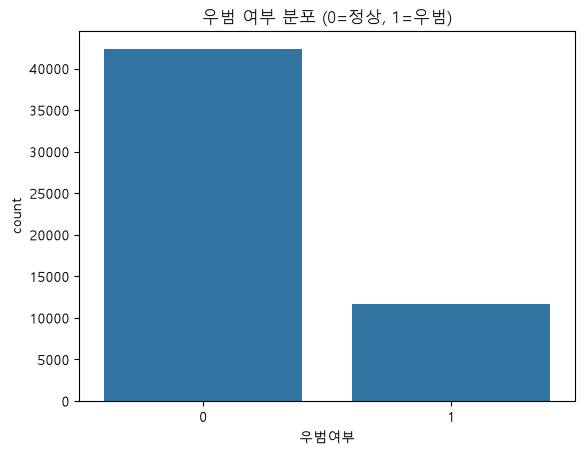

In [11]:
# 우범여부 분포를 막대그래프로 시각화 하세요.
sns.countplot(data=df, x='우범여부')
plt.title('우범 여부 분포 (0=정상, 1=우범)')
plt.show()

<br/>
<br/>

### 범주형 변수 별 우범 비율
- 특정 운송수단·원산지 표시 방법에서 우범 비율이 높은지 확인합니다. (예측에 유용한 신호 탐색)

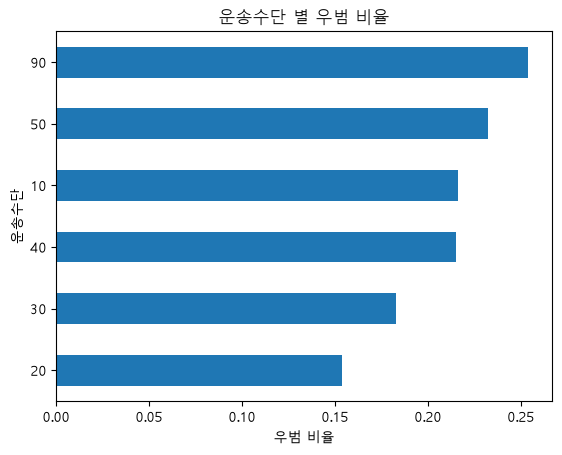

In [12]:
# 운송수단 별 평균 우범 비율을 시각화 하세요.
df.groupby('운송수단')['우범여부'].mean().sort_values().plot(kind='barh')
plt.title('운송수단 별 우범 비율')
plt.xlabel('우범 비율')
plt.show()

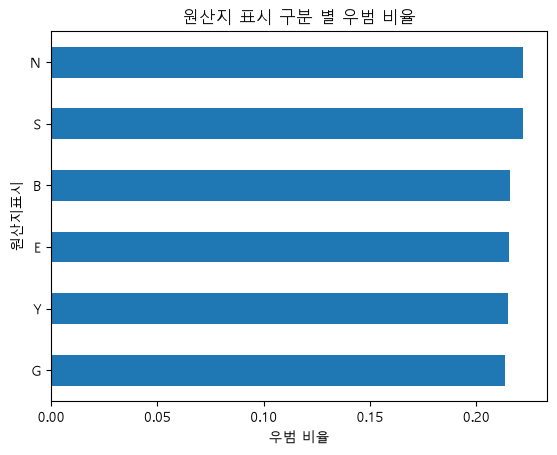

In [13]:
# 원산지표시 별 평균 우범 비율을 시각화 하세요.
df.groupby('원산지표시')['우범여부'].mean().sort_values().plot(kind='barh')
plt.title('원산지 표시 구분 별 우범 비율')
plt.xlabel('우범 비율')
plt.show()

<br/>
<br/>

### 수치형 변수 분포
- `순중량`, `신고가격` 은 값의 범위가 매우 넓고 오른쪽으로 크게 치우쳐 있습니다. (나중에 로그 변환 대상)

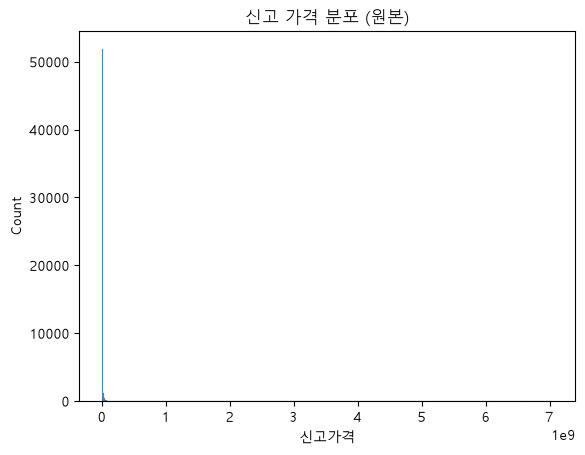

In [14]:
# 신고가격의 분포를 히스토그램으로 확인하세요.
sns.histplot(df['신고가격'])
plt.title('신고 가격 분포 (원본)')
plt.show()

<br/>
<br/>

## 2. 데이터 전처리

### 불필요 · 누수 컬럼 제거
- **ID 컬럼**(`신고번호`, `신고인부호`, `수입자부호`, `판매자부호`, `특송업체부호`): 고유값이 너무 많아 학습에 부적합 → 제거
- **`중대우범여부`**: 우범 여부가 이미 반영된 또 다른 정답 라벨 → **데이터 누수**이므로 제거
- `신고일자`, `HS6단위` 는 5단계에서 파생 변수로 활용하기 위해 잠시 남겨둡니다.

In [15]:
# 위의 ID 컬럼들과 중대우범여부를 제거하세요.
drop_cols = ['신고번호', '신고인부호', '수입자부호',
             '판매자부호', '특송업체부호', '중대우범여부']
df = df.drop(columns=drop_cols)
df.shape

(54000, 16)

<br/>
<br/>

### 범주형 컬럼 타입 변환
- `세관부호`, `수입유형` 등은 숫자로 저장돼 있지만 **의미상 범주형** 입니다. 원핫 인코딩이 올바르게 되도록 문자열(str)로 변환합니다.

In [16]:
# 범주형 컬럼(cat_cols)을 문자열로 변환하세요.
cat_cols = ['세관부호', '신고구분', '수입유형', '수입용도', '납부방법',
        '운송수단', '관세종류', '원산지표시', '적출국', '원산지국']
df[cat_cols] = df[cat_cols].astype(str)
df[cat_cols].dtypes

세관부호     str
신고구분     str
수입유형     str
수입용도     str
납부방법     str
운송수단     str
관세종류     str
원산지표시    str
적출국      str
원산지국     str
dtype: object

<br/>
<br/>

## 3. 머신러닝 적용 (1차) — 기본 피처
- 원본 범주형/수치형 컬럼을 그대로 사용합니다.
- 각 모델은 `model.score()` 로 **정확도(train, test)** 를 확인하고, 마지막 셀에서 **재현율·F1** 을 함께 비교합니다.

### X, y 분리 & 원핫 인코딩

In [17]:
# cat_cols + 수치형 컬럼으로 X를, 우범여부로 y를 만드세요.
num_cols = ['세율', '순중량', '신고가격']
X = df[cat_cols + num_cols]
y = df['우범여부']
X_onehot = pd.get_dummies(X, columns=cat_cols)
X_onehot.shape

(54000, 383)

In [18]:
# 학습/검증 분리 (불균형이므로 stratify=y, random_state=0)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_onehot, y, test_size=0.25, random_state=0, stratify=y)
X_train.shape, X_test.shape

((40500, 383), (13500, 383))

<br/>
<br/>

In [19]:
# RandomForestClassifier 적용
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
rf.score(X_train, y_train), rf.score(X_test, y_test)

(0.9990617283950617, 0.8114074074074074)

In [20]:
# XGBClassifier 적용
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=0)
xgb.fit(X_train, y_train)
xgb.score(X_train, y_train), xgb.score(X_test, y_test)

(0.8191111111111111, 0.8067407407407408)

In [21]:
# LGBMClassifier 적용
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=0, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm.score(X_train, y_train), lgbm.score(X_test, y_test)

(0.8033333333333333, 0.795037037037037)

In [22]:
# 각 모델의 재현율(recall)과 F1 점수를 비교하세요.
from sklearn.metrics import recall_score, f1_score
models = {'RandomForest': rf, 'XGBoost': xgb, 'LightGBM': lgbm}
for name, model in models.items():
    pred = model.predict(X_test)
    print(f'{name:15s} 재현율={recall_score(y_test, pred):.4f}  F1={f1_score(y_test, pred):.4f}')

RandomForest    재현율=0.2242  F1=0.3390
XGBoost         재현율=0.1308  F1=0.2260
LightGBM        재현율=0.0690  F1=0.1269


### ⚠️ 결과 해석 : 정확도의 함정
- 세 모델 모두 **정확도는 약 0.79~0.81 로 높아 보이지만**, 재현율(실제 우범을 잡아낸 비율)은 매우 낮습니다.
    → 예: **LightGBM 은 정확도 0.80 인데 재현율 0.07** — 실제 우범의 약 93%를 놓칩니다.
- 데이터의 78%가 정상이라 **무조건 '정상'에 가깝게 찍어도 정확도는 높게** 나오기 때문입니다.
- 이것이 불균형 데이터에서 정확도만 보면 안 되는 이유입니다. **재현율·F1** 을 함께 봐야 합니다.
- 다음 단계에서 **불균형 처리**로 이 문제를 개선합니다.

<br/>
<br/>

## 4. 성능 개선 ① — 로그 변환 · 불균형 처리
- `순중량`, `신고가격` 은 값의 범위가 매우 넓어 **로그 변환** 으로 분포를 완만하게 만듭니다.
- 모델에 **`class_weight='balanced'` / `scale_pos_weight`** 를 주어 소수 클래스(우범)에 가중치를 부여합니다. → 이번 단계의 **핵심 지렛대**
- (참고: 스케일링은 표준 전처리로 함께 적용하지만, 트리 계열 모델은 스케일에 영향을 받지 않습니다.)

### 로그 변환

In [23]:
# 순중량, 신고가격에 np.log1p를 적용하여 새 컬럼을 만드세요.
df['log_순중량'] = np.log1p(df['순중량'])
df['log_신고가격'] = np.log1p(df['신고가격'])
df[['log_순중량', 'log_신고가격']].describe()

,log_순중량,log_신고가격
count,54000.000000,54000.000000
mean,4.941544,9.268974
std,3.206423,4.182117
min,0.000000,0.000000
25%,2.341806,6.230747
50%,4.564348,9.177094
75%,7.334982,12.362330
max,17.910272,22.675681


<br/>
<br/>

### X, y 분리 & 원핫 인코딩 & 스케일링

In [24]:
# 로그 변환 컬럼을 사용하여 X_onehot을 만드세요.
num_cols = ['세율', 'log_순중량', 'log_신고가격']
X = df[cat_cols + num_cols]
y = df['우범여부']
X_onehot = pd.get_dummies(X, columns=cat_cols)
X_onehot.shape

(54000, 383)

In [25]:
# 학습/검증 분리 후 StandardScaler로 스케일링 하세요.
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X_onehot, y, test_size=0.25, random_state=0, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape, X_test.shape

((40500, 383), (13500, 383))

<br/>
<br/>

### 머신러닝 적용 (2차)

In [26]:
# RandomForestClassifier 적용
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
rf.score(X_train, y_train), rf.score(X_test, y_test)

(0.9979506172839506, 0.7908148148148149)

In [27]:
# XGBClassifier 적용  (scale_pos_weight로 불균형 보정)
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=0, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
xgb.fit(X_train, y_train)
xgb.score(X_train, y_train), xgb.score(X_test, y_test)

(0.7198765432098766, 0.6807407407407408)

In [28]:
# LGBMClassifier 적용
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=0, class_weight='balanced', verbose=-1)
lgbm.fit(X_train, y_train)
lgbm.score(X_train, y_train), lgbm.score(X_test, y_test)

(0.6679012345679012, 0.6365185185185185)

In [29]:
# 각 모델의 재현율(recall)과 F1 점수를 비교하세요.
from sklearn.metrics import recall_score, f1_score
models = {'RandomForest': rf, 'XGBoost': xgb, 'LightGBM': lgbm}
for name, model in models.items():
    pred = model.predict(X_test)
    print(f'{name:15s} 재현율={recall_score(y_test, pred):.4f}  F1={f1_score(y_test, pred):.4f}')

RandomForest    재현율=0.4236  F1=0.4664
XGBoost         재현율=0.7233  F1=0.4944
LightGBM        재현율=0.7501  F1=0.4711


### 결과 해석
- 불균형 처리 후 **재현율과 F1 이 크게 상승** 했습니다. (예: XGBoost 재현율 0.13 → 0.72, LightGBM 재현율 0.07 → 0.75)
- 정확도는 오히려 조금 떨어질 수 있는데, 이는 **우범을 더 적극적으로 잡아내는 대신** 정상 일부를 우범으로 오판하기 때문입니다.
- 관세 우범 선별에서는 **놓치지 않는 것(재현율)** 이 중요하므로 바람직한 방향입니다.

<br/>
<br/>

## 5. 성능 개선 ② — 파생 변수 생성
- 도메인 지식을 활용해 새 변수를 만듭니다.
    - **월 / 요일** : `신고일자` 에서 신고 월·요일 추출
    - **HS대분류** : HS6 코드 앞 2자리(품목 대분류)
    - **단가** : 신고가격 ÷ 순중량 (무게당 단가) — 저가 신고 탐지에 유용
    - **원산지불일치** : 적출국 ≠ 원산지국 여부

### 파생 변수 생성

In [30]:
# 신고일자를 datetime으로 변환하고 월, 요일을 추출하세요.
df['신고일자'] = pd.to_datetime(df['신고일자'])
df['월'] = df['신고일자'].dt.month.astype(str)
df['요일'] = df['신고일자'].dt.weekday.astype(str)
df[['신고일자', '월', '요일']].head()

,신고일자,월,요일
0,2020-01-01,1,2
1,2020-01-01,1,2
2,2020-01-01,1,2
3,2020-01-01,1,2
4,2020-01-01,1,2


In [31]:
# HS대분류(앞 2자리), 단가(로그), 원산지불일치를 만드세요.
df['HS대분류'] = (df['HS6단위'] // 10000).astype(str)
df['단가'] = np.log1p(df['신고가격'] / (df['순중량'] + 1))
df['원산지불일치'] = (df['적출국'] != df['원산지국']).astype(int)
df[['HS대분류', '단가', '원산지불일치']].head()

,HS대분류,단가,원산지불일치
0,44,8.136278,0
1,69,3.529212,0
2,62,5.512149,0
3,94,5.083158,0
4,7,5.584206,0


<br/>
<br/>

### X, y 분리 & 원핫 인코딩 & 스케일링

In [32]:
# 파생 변수를 포함하여 X_onehot을 만드세요.
cat_cols2 = cat_cols + ['HS대분류', '월', '요일']
num_cols = ['세율', 'log_순중량', 'log_신고가격', '단가', '원산지불일치']
X = df[cat_cols2 + num_cols]
y = df['우범여부']
X_onehot = pd.get_dummies(X, columns=cat_cols2)
X_onehot.shape

(54000, 498)

In [33]:
# 학습/검증 분리 후 스케일링 하세요.
X_train, X_test, y_train, y_test = train_test_split(
    X_onehot, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape, X_test.shape

((40500, 498), (13500, 498))

<br/>
<br/>

### 머신러닝 적용 (3차)

In [34]:
# RandomForestClassifier 적용
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
rf.score(X_train, y_train), rf.score(X_test, y_test)

(0.9999259259259259, 0.8526666666666667)

In [35]:
# XGBClassifier 적용  (scale_pos_weight로 불균형 보정)
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=0, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
xgb.fit(X_train, y_train)
xgb.score(X_train, y_train), xgb.score(X_test, y_test)

(0.7477283950617284, 0.7091851851851851)

In [36]:
# LGBMClassifier 적용
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=0, class_weight='balanced', verbose=-1)
lgbm.fit(X_train, y_train)
lgbm.score(X_train, y_train), lgbm.score(X_test, y_test)

(0.7129876543209877, 0.672)

In [37]:
# 각 모델의 재현율(recall)과 F1 점수를 비교하세요.
from sklearn.metrics import recall_score, f1_score
models = {'RandomForest': rf, 'XGBoost': xgb, 'LightGBM': lgbm}
for name, model in models.items():
    pred = model.predict(X_test)
    print(f'{name:15s} 재현율={recall_score(y_test, pred):.4f}  F1={f1_score(y_test, pred):.4f}')

RandomForest    재현율=0.4991  F1=0.5938
XGBoost         재현율=0.7573  F1=0.5291
LightGBM        재현율=0.7384  F1=0.4928


### 결과 해석
- 파생 변수 추가 후 **RandomForest · XGBoost 등 앙상블 모델의 F1 이 상승** 했습니다. (예: RandomForest F1 0.47 → 0.59)
- 무게당 단가(`단가`), 품목 대분류(`HS대분류`) 등이 우범을 구분하는 신호를 제공했습니다.

<br/>
<br/>

## 6. 최종 모델 변수 중요도
- 앙상블이라 단일 트리보다 과적합에 강하고 안정적인 **RandomForest** 를 최종 모델로 사용합니다.
- 어떤 변수가 우범 예측에 크게 기여했는지 확인합니다.

In [38]:
# 최종 모델(RandomForest, class_weight='balanced')을 학습하세요.
final_model = RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1)
final_model.fit(X_train, y_train)
final_model.score(X_train, y_train), final_model.score(X_test, y_test)

(0.9999259259259259, 0.8526666666666667)

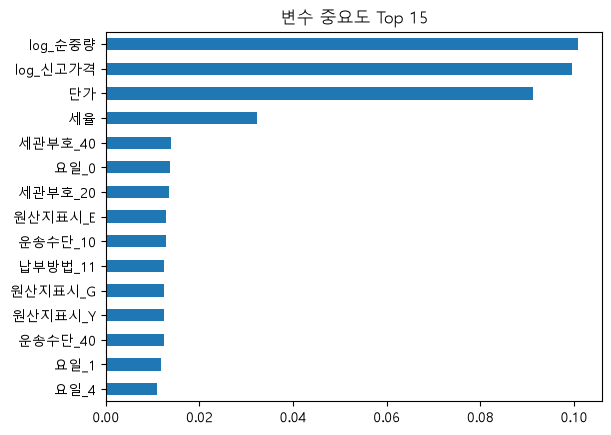

In [39]:
# 변수 중요도 상위 15개를 막대그래프로 시각화 하세요.
importance = pd.Series(final_model.feature_importances_, index=X_onehot.columns)
importance.sort_values(ascending=False).head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('변수 중요도 Top 15')
plt.show()

<br/>
<br/>

## 정리
| 단계 | 전처리 | 핵심 효과 |
|:--|:--|:--|
| 1차 | 원본 피처 | 정확도는 높으나 재현율 낮음 (정확도의 함정) |
| 2차 | 로그·스케일링 + **불균형 처리** | 재현율·F1 대폭 상승 |
| 3차 | 파생 변수 생성 | 앙상블 F1 상승 → 최고 성능 |

- **핵심 교훈**
    1. 불균형 데이터에서는 정확도가 아닌 **재현율 · F1** 을 봐야 한다.
    2. **`class_weight` / `scale_pos_weight`** 로 소수 클래스를 잡아내는 능력을 높인다.
    3. 도메인 기반 **파생 변수**(단가·대분류 등)가 성능을 끌어올린다.